# 0. Data Denoise & Preprocessing

**Objective**: Load raw electrophysiology data, visualize LFP, and construct the Neural Response Matrix.

**Steps**:
1.  Load AllenSDK Session.
2.  Visualize Local Field Potentials (LFP).
3.  Construct `average_response_matrix_total` (Frames x Neurons).
4.  Save the processed matrix for downstream analysis.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache

# Import Architectural Style
import viz_style
viz_style.set_architectural_style()

# Setup Cache
output_dir = "../Dataset/RAW"
manifest_path = os.path.join(output_dir, "manifest.json")
cache = EcephysProjectCache.from_warehouse(manifest=manifest_path)

session_id = 715093703
session = cache.get_session_data(session_id)
print(f"Session {session_id} loaded successfully.")

Architectural plot style applied (Dark Mode).


/opt/anaconda3/envs/TDA/lib/python3.11/site-packages/hdmf/spec/namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.2.2, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


Session 715093703 loaded successfully.


### Step 1: LFP Visualization
Visualize the raw Local Field Potential traces to inspect signal quality.

Loading LFP for Probe 810755797...


/opt/anaconda3/envs/TDA/lib/python3.11/site-packages/hdmf/spec/namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.2.2, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)
/opt/anaconda3/envs/TDA/lib/python3.11/site-packages/hdmf/spec/namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.2.2, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


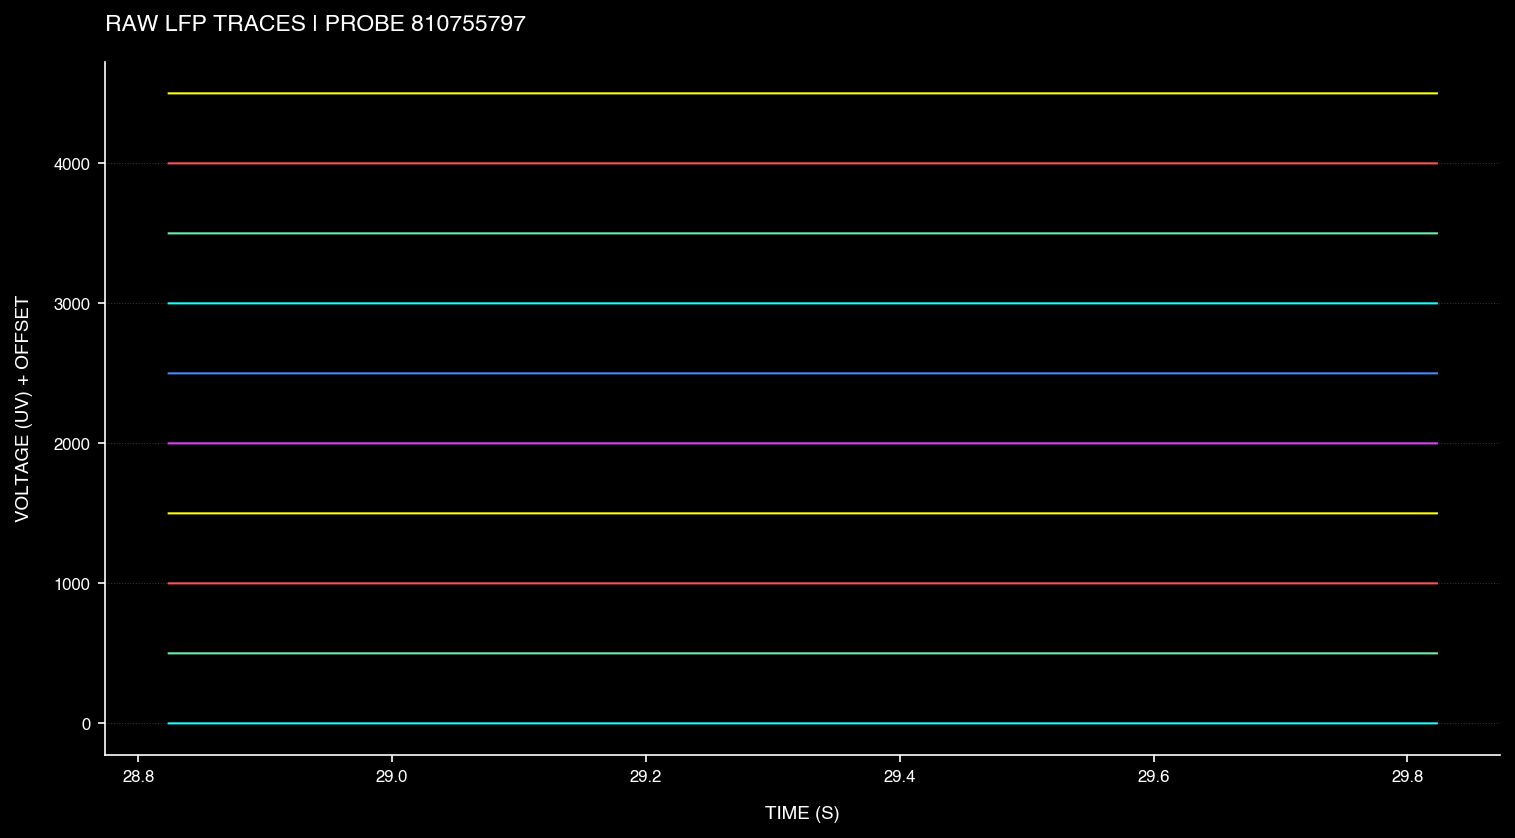

In [2]:
try:
    # Select a probe
    target_probe_id = session.probes.index[0]
    print(f"Loading LFP for Probe {target_probe_id}...")
    
    lfp = session.get_lfp(target_probe_id)
    
    # Plot LFP
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot a small time window (e.g., 1 second)
    start_time = lfp.time.min()
    end_time = start_time + 1.0
    
    start_idx = np.searchsorted(lfp.time, start_time)
    end_idx = np.searchsorted(lfp.time, end_time)
    
    # Use a cycle of neon colors
    colors = [viz_style.CYAN, viz_style.GREEN, viz_style.RED, viz_style.YELLOW, viz_style.PURPLE, viz_style.BLUE]
    
    for i in range(10):
        color = colors[i % len(colors)]
        # Offset traces for visibility
        ax.plot(lfp.time[start_idx:end_idx], lfp.data[start_idx:end_idx, i] + i*500, label=f"Ch {i}", color=color, linewidth=1)
    
    viz_style.format_axis(
        ax,
        title=f"RAW LFP TRACES | PROBE {target_probe_id}",
        xlabel="TIME (S)",
        ylabel="VOLTAGE (uV) + OFFSET"
    )
    
    plt.show()

except Exception as e:
    print(f"\nCould not load LFP data: {e}")
    print("LFP data might not be downloaded. Check your manifest or download settings.")

### Step 2: Construct Neural Response Matrix
Align spike times with the "Natural Movie One" frames to create a (Frames x Neurons) response matrix.

In [3]:
movie_table = session.get_stimulus_table("natural_movie_one")
print(f"Total Presentations (Frames x Repeats): {len(movie_table)}")

frame_duration = movie_table['duration'].mean()
print(f"Time Window per Frame: {frame_duration:.4f} s")

all_units = session.units
print(f"Total Units in Session: {len(all_units)}")

print("Calculating spike counts for ALL units... (this will take longer)")
spike_counts_all_xr = session.presentationwise_spike_counts(
    stimulus_presentation_ids=movie_table.index.values,
    bin_edges=np.array([0, frame_duration]),
    unit_ids=all_units.index.values
)

response_matrix_total = spike_counts_all_xr.sum(dim="time_relative_to_stimulus_onset")

df_response_total = pd.DataFrame(
    response_matrix_total.values,
    index=movie_table.index,
    columns=all_units.index
)
df_response_total['frame'] = movie_table['frame']

# Average across repeats to get (Frames x Neurons)
average_response_matrix_total = df_response_total.groupby('frame').mean()

print("\n--- Final Response Matrix Created ---")
print(f"Shape: {average_response_matrix_total.shape} (Frames x Neurons)")
display(average_response_matrix_total.head())

/opt/anaconda3/envs/TDA/lib/python3.11/site-packages/hdmf/spec/namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.2.2, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


Total Presentations (Frames x Repeats): 18000
Time Window per Frame: 0.0334 s
Total Units in Session: 884
Calculating spike counts for ALL units... (this will take longer)

--- Final Response Matrix Created ---
Shape: (900, 884) (Frames x Neurons)


unit_id,950910352,950910364,950910371,950910392,950910435,950910463,950910531,950910576,950910558,950910549,...,950956667,950956514,950956778,950957408,950956835,950956911,950956870,950956845,950956952,950957053
frame,,,,,,,,,,,,,,,,,,,,,
0.0,0.10,1.00,0.40,0.35,2.45,0.25,0.50,0.50,0.90,0.15,...,0.20,0.10,0.50,0.0,0.0,0.15,0.0,0.0,0.65,0.00
1.0,0.15,1.35,0.60,0.40,2.15,0.65,0.65,0.65,1.00,0.25,...,0.15,0.05,0.45,0.0,0.0,0.20,0.0,0.0,0.85,0.05
2.0,0.20,1.15,0.40,0.40,2.35,0.50,0.75,0.50,0.45,0.35,...,0.50,0.00,0.70,0.0,0.0,0.20,0.0,0.0,1.80,0.10
3.0,0.10,0.90,0.70,0.60,2.30,0.15,0.45,0.35,0.60,0.25,...,0.25,0.00,0.60,0.0,0.0,0.10,0.0,0.0,1.05,0.15
4.0,0.05,0.50,0.55,0.60,2.15,0.60,0.40,0.15,1.60,0.15,...,0.20,0.05,0.40,0.0,0.0,0.15,0.0,0.0,1.00,0.10


### Step 3: Visualization of Whole Brain Response

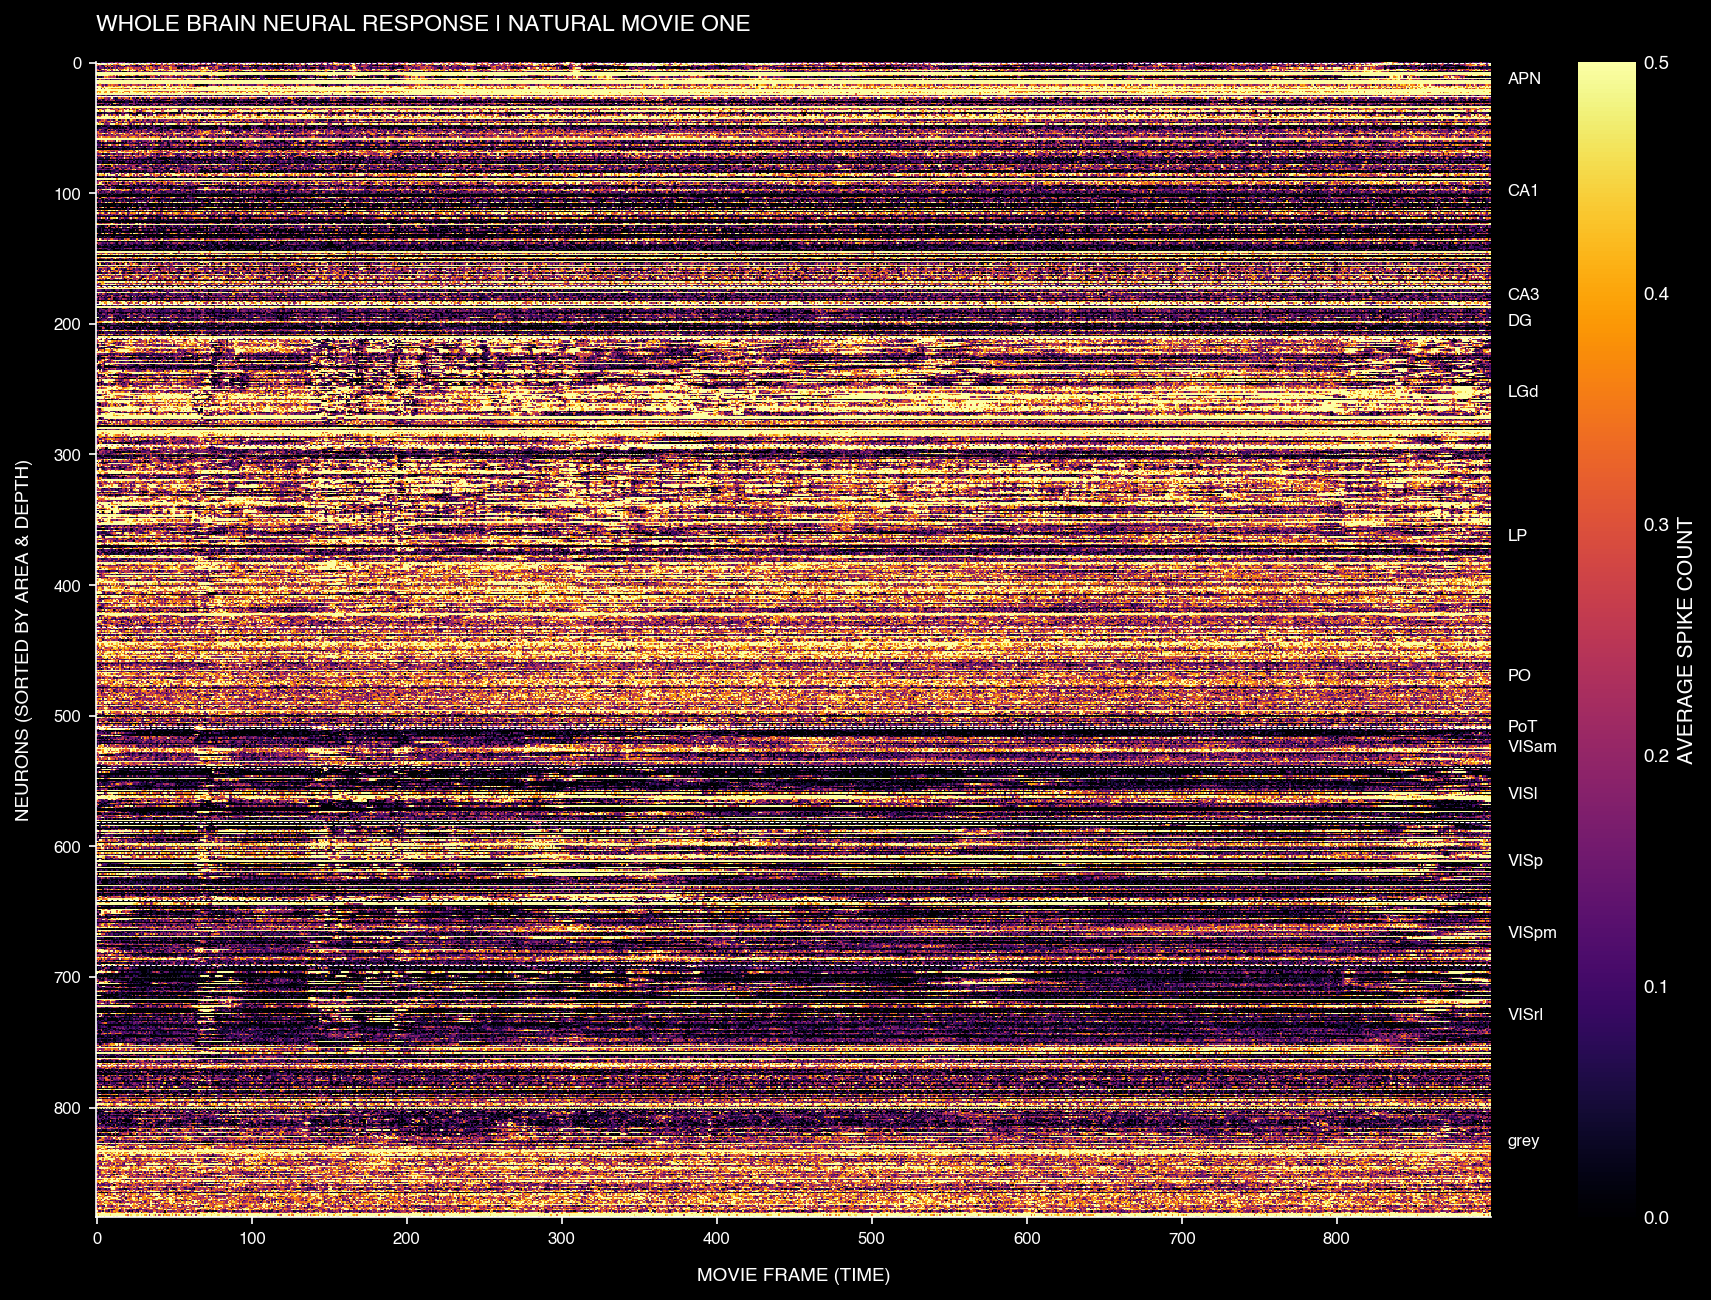

In [4]:
sorted_all_units = all_units.sort_values(
    by=["ecephys_structure_acronym", "probe_vertical_position"], 
    ascending=[True, False]
)

sorted_response_matrix_total = average_response_matrix_total[sorted_all_units.index]

fig, ax = plt.subplots(figsize=(15, 10))
im = ax.imshow(sorted_response_matrix_total.T, aspect='auto', cmap='inferno', interpolation='none', vmin=0, vmax=0.5) 

viz_style.format_axis(
    ax,
    title="WHOLE BRAIN NEURAL RESPONSE | NATURAL MOVIE ONE",
    xlabel="MOVIE FRAME (TIME)",
    ylabel="NEURONS (SORTED BY AREA & DEPTH)"
)

cbar = plt.colorbar(im, label="Average Spike Count")
cbar.outline.set_visible(False)
cbar.ax.tick_params(size=0, colors=viz_style.WHITE)
cbar.set_label("AVERAGE SPIKE COUNT", color=viz_style.WHITE)

# Add Area Labels
area_counts = sorted_all_units['ecephys_structure_acronym'].value_counts(sort=False)
current_idx = 0
for area, group in sorted_all_units.groupby("ecephys_structure_acronym", sort=True):
    count = len(group)
    ax.axhline(y=current_idx, color=viz_style.WHITE, linestyle='--', linewidth=0.5)
    ax.text(910, current_idx + count/2, area, verticalalignment='center', fontsize=8, color=viz_style.WHITE)
    current_idx += count

plt.show()

### Step 4: Save Processed Data
Save the `average_response_matrix_total` to disk so it can be loaded in subsequent notebooks.

In [5]:
output_dir = Path("../Dataset/Processed") / str(session_id)
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / "average_response_matrix.pkl"
average_response_matrix_total.to_pickle(output_file)

print(f"Data saved to: {output_file}")

Data saved to: ../Dataset/Processed/715093703/average_response_matrix.pkl
